In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('orings.csv')
df.head()

,mission,temperature,damaged,undamaged
0,1,53,5,1
1,2,57,1,5
2,3,58,1,5
3,4,63,1,5
4,5,66,0,6


In [14]:
#Frage 1: Was bedeuten die Parameter theta0 und theta1 in ihrer logistischen Regression?

#theta0: Dieser Parameter ist der Achsenabschnitt der logistischen Regression. 
#Es ist der Grundwert der Log-Odds, wenn alle Features = 0 sind. Also-> log(p/(1-p)) = theta0 (wenn alle x =0 sind)
#theta1: Das ist der Steigungseinfluss von x1. Wenn x um 1 steigt, ändern sich die Log-Odds um theta1.
#Die Odds werden mit exp(theta1) multipliziert.

In [15]:
# Daten vorbereiten
y = (df['damaged'] > 0).astype(int).values  # 1 = mindestens ein Ausfall

temp_mean = df['temperature'].mean() # Mittelwert der Temperatur berechnen
temp_std = df['temperature'].std() # Standardabweichung der Temperatur berechnen

# Temperatur in °F normalisieren / Standardisieren -> Bewirkt dass Mittelwert 0 wird und Standardabweichung 1 -> Stabilere Optimierung
X_temp = ((df['temperature'] - temp_mean) / temp_std).values.reshape(-1, 1) # reshape(-1, 1) macht aus einem 1D-Array ein 2D-Array mit einer Spalte (für die Matrixoperationen)

# Matrixschreibweise Designematrix:
X = np.hstack([np.ones((len(X_temp), 1)), X_temp])  # erste Spalte ist der Intercept
# X = [1, Temperatur1]
#     [1, Temperatur2]

print('Anzahl Datenpunkte:', len(y))   # Anzahl der Datenpunkte (Anzahl der Zeilen im DataFrame)
print('X shape:', X.shape) # X shape: (n_samples, n_features) -> n_samples = Anzahl der Datenpunkte, n_features = Anzahl der Merkmale (hier 2: Intercept und normalisierte Temperatur)

Anzahl Datenpunkte: 23
X shape: (23, 2)


In [16]:
# Sigmoid funktion
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [17]:
# Log-Loss Kostenfunktion
def log_loss(y_true, y_prob):
    y_prob = np.clip(y_prob, 1e-8, 1 - 1e-8)# np.clip verhindert log(0) Fehler indem es die Werte von y_prob auf einen Bereich zwischen 1e-8 und 1 - 1e-8 beschränkt.
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob)) # Berechnung der Log-Loss-Kostenfunktion für die wahren Labels (y_true) und die vorhergesagten Wahrscheinlichkeiten (y_prob)

In [18]:
# Training mit Gradient Descent (der Berg und das Tal)
def train_logreg_simple(X, y, lr=0.1, n_steps=10000):# 10000 ist der default Wert für die Anzahl der Schritte, die der Gradient Descent durchlaufen soll. Es ist eine gängige Wahl, um sicherzustellen, dass das Modell genügend Zeit hat, um zu konvergieren.
    theta = np.zeros(X.shape[1])
    losses = []
    theta_history = []

    for _ in range(n_steps):
        probs = sigmoid(X @ theta) #@ macht eine Matrixmultiplikation zwischen X und theta, um die Log-Odds zu berechnen, und die Sigmoid-Funktion wandelt diese Log-Odds in Wahrscheinlichkeiten um.
       
        # Gradient in Matrixschreibweise
        grad = (X.T @ (probs - y)) / len(y)
        theta = theta - lr * grad #theta learningrate*gradient

        # Kosten pro Iteration speichern, damit der Verlauf später geplottet werden kann
        losses.append(log_loss(y, probs))
        theta_history.append(theta.copy())

    return theta, losses, theta_history

In [19]:
#Optional: genaue Berechnung für ein gegebenes theta
def compute_cost(X, y, theta):
   probs = sigmoid(X @ theta) # @ macht die Matrixmultiplikation
   return log_loss(y, probs)

In [20]:
# Manuelle Implementierung ausführen
learning_rate = 0.1
iterations = 10000

theta_manual, costs_manual, theta_history_manual = train_logreg_simple(X, y, lr=learning_rate, n_steps=iterations)

theta0 = theta_manual[0]
theta1 = theta_manual[1]

print('Manuelle Koeffizienten:')
print(f'  theta0 (Intercept): {theta0:.6f}')
print(f'  theta1 (Temperatur): {theta1:.6f}')
print(f'Endkosten (Log-Loss): {costs_manual[-1]:.6f}')

# Frage 2: 50%-Schwelle und Challenger bei 31°F
T50 = -theta0 / theta1
print(f'Temperatur bei 50% Ausfallwahrscheinlichkeit: {T50:.2f}°F')

p31 = sigmoid(np.array([1, (31.0 - temp_mean) / temp_std]) @ theta_manual)
print(f'Ausfallwahrscheinlichkeit bei 31°F: {p31:.4f}')

Manuelle Koeffizienten:
  theta0 (Intercept): -1.107550
  theta1 (Temperatur): -1.638391
Endkosten (Log-Loss): 0.441635
Temperatur bei 50% Ausfallwahrscheinlichkeit: -0.68°F
Ausfallwahrscheinlichkeit bei 31°F: 0.9996


In [21]:
# Vergleich mit sklearn
from sklearn.linear_model import LogisticRegression

X_temp_norm = ((df['temperature'] - temp_mean) / temp_std).values.reshape(-1, 1)

# C sehr groß -> fast keine Regularisierung
model = LogisticRegression(C=1e6, max_iter=1000)
model.fit(X_temp_norm, y)

theta0_sk = model.intercept_[0]
theta1_sk = model.coef_[0, 0]

print('Sklearn Koeffizienten:')
print(f'  theta0 (Intercept): {theta0_sk:.6f}')
print(f'  theta1 (Temperatur): {theta1_sk:.6f}')

h_sk = model.predict_proba(X_temp_norm)[:, 1]
cost_sk = log_loss(y, h_sk)
print(f'Sklearn Kosten (Log-Loss): {cost_sk:.6f}')

Sklearn Koeffizienten:
  theta0 (Intercept): -1.107547
  theta1 (Temperatur): -1.638391
Sklearn Kosten (Log-Loss): 0.441635


Entscheidungsschwelle (p=0.5) bei ca. 64.8°F


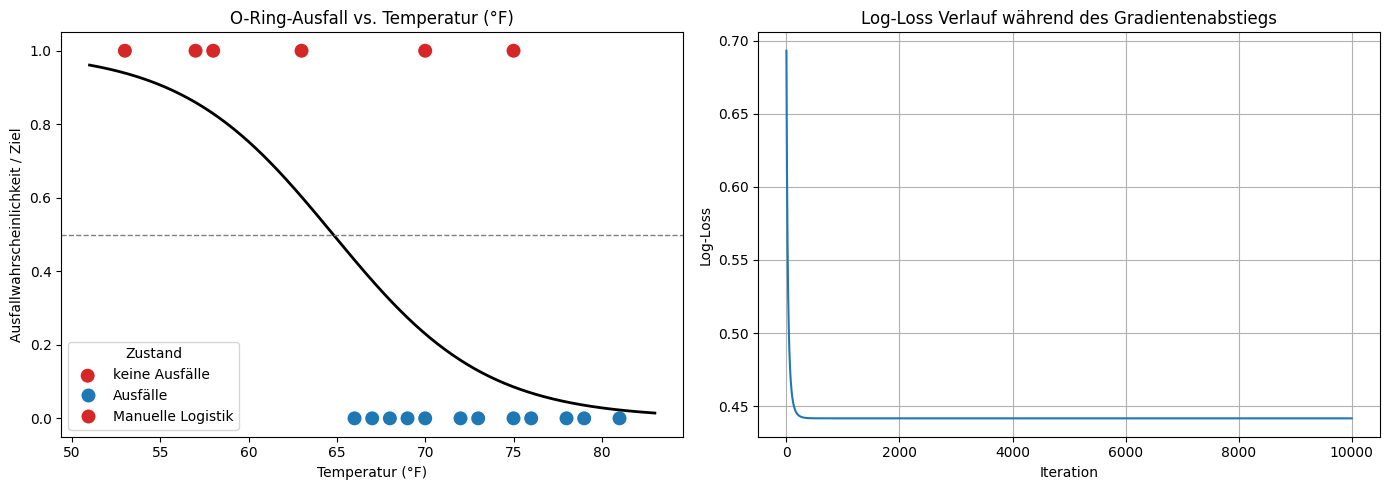

In [22]:
# Ergebnisse graphisch darstellen
temp = df['temperature'].values
temp_norm = ((temp - temp_mean) / temp_std)

# Wahrscheinlichkeiten für manuelle Lösung
prob_manual = sigmoid(np.column_stack([np.ones(len(temp_norm)), temp_norm]) @ theta_manual)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)

sns.scatterplot(x=temp, y=y, hue=y, palette=['tab:blue', 'tab:red'], s=120)

# Glatte Temperaturkurve für Vorhersage in °F
temp_plot = np.linspace(temp.min() - 2, temp.max() + 2, 300)
temp_plot_norm = (temp_plot - temp_mean) / temp_std
prob_curve = sigmoid(np.column_stack([np.ones(len(temp_plot_norm)), temp_plot_norm]) @ theta_manual)

plt.plot(temp_plot, prob_curve, color='black', linewidth=2, label='Manuelle Logistik')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.title('O-Ring-Ausfall vs. Temperatur (°F)')
plt.xlabel('Temperatur (°F)')
plt.ylabel('Ausfallwahrscheinlichkeit / Ziel')
plt.legend(title='Zustand', labels=['keine Ausfälle', 'Ausfälle', 'Manuelle Logistik'])

plt.subplot(1, 2, 2)
plt.plot(costs_manual, color='tab:blue')
plt.title('Log-Loss Verlauf während des Gradientenabstiegs')
plt.xlabel('Iteration')
plt.ylabel('Log-Loss')
plt.grid(True)

plt.tight_layout()

threshold_index = np.argmin(np.abs(prob_curve - 0.5))
threshold_temp = temp_plot[threshold_index]
print(f'Entscheidungsschwelle (p=0.5) bei ca. {threshold_temp:.1f}°F')

In [23]:
# Vorhersage für neue Temperaturen
# Einfach Werte in new_temps eintragen
new_temps = np.array([55, 65, 75], dtype=float)

new_temps_norm = (new_temps - temp_mean) / temp_std
X_new = np.column_stack([np.ones(len(new_temps_norm)), new_temps_norm])
probs = sigmoid(X_new @ theta_manual)

for temp_val, prob in zip(new_temps, probs):
    print(f'Temperatur {temp_val:.1f}°F -> Ausfallwahrscheinlichkeit: {prob*100:.1f}%')

Temperatur 55.0°F -> Ausfallwahrscheinlichkeit: 90.7%
Temperatur 65.0°F -> Ausfallwahrscheinlichkeit: 48.8%
Temperatur 75.0°F -> Ausfallwahrscheinlichkeit: 8.6%


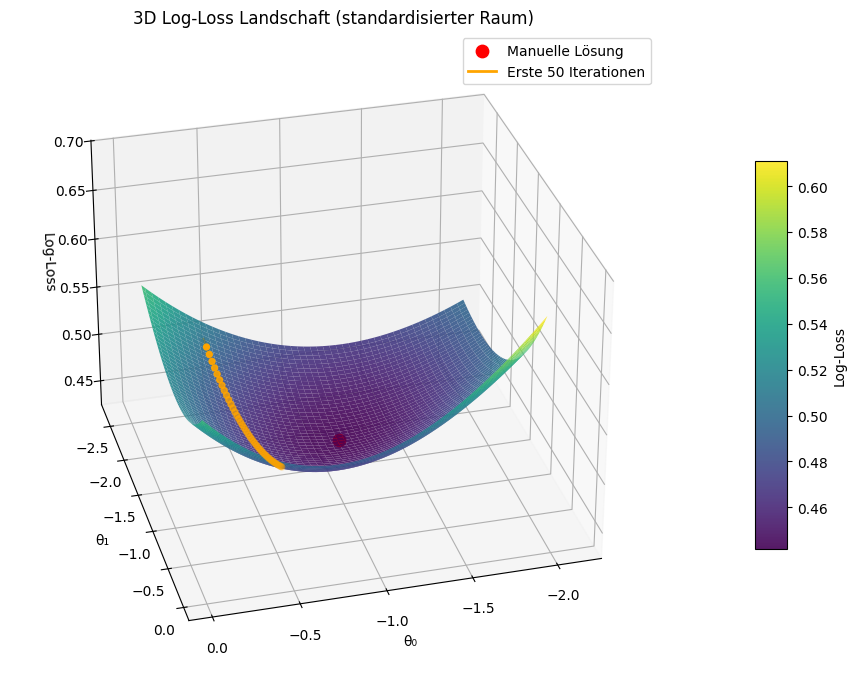

In [24]:
# 3D-Visualisierung der Log-Loss Landschaft im standardisierten Parameterraum
theta0_range = np.linspace(theta0 - 1, theta0 + 1, 100) #Feinere Bereiche um die gefundenen Koeffizienten
theta1_range = np.linspace(theta1 - 1, theta1 + 1, 100)
Theta0, Theta1 = np.meshgrid(theta0_range, theta1_range) #Erstellen eines Gitters von theta0 und theta1 Werten
Loss_landscape = np.zeros_like(Theta0) #Initialisieren einer Matrix für die Log-Loss Werte

for i in range(Theta0.shape[0]): #Durchlaufen aller Punkte im Gitter
    for j in range(Theta0.shape[1]):
        theta_temp = np.array([Theta0[i, j], Theta1[i, j]])
        Loss_landscape[i, j] = compute_cost(X, y, theta_temp)

loss_manual = compute_cost(X, y, np.array([theta0, theta1])) #Log-Loss für die manuelle Lösung


# Visualisierung der ersten 50 Iterationen auf der Log-Loss Landschaft
theta_path = np.array(theta_history_manual[:51]) #Erstellen eines Arrays der Log-Loss Werte entlang des Pfades der ersten 50 Iterationen
path_losses = np.array([compute_cost(X, y, theta_step) for theta_step in theta_path]) #Berechnung der Log-Loss Werte für jeden Punkt auf dem Pfad der ersten 50 Iterationen

fig = plt.figure(figsize=(10, 7)) 
ax = fig.add_subplot(111, projection='3d') 

surface = ax.plot_surface( 
    Theta0, Theta1, Loss_landscape,
    cmap='viridis',
    edgecolor='none',
    alpha=0.9
 ) #Log-Loss Landschaft als Oberfläche
fig.colorbar(surface, shrink=0.6, aspect=12, pad=0.1, label='Log-Loss')

ax.scatter(theta0, theta1, loss_manual, color='red', s=80, label='Manuelle Lösung') #Punkt der manuellen Lösung auf der Landschaft
ax.plot(theta_path[:, 0], theta_path[:, 1], path_losses, color='orange', linewidth=2, label='Erste 50 Iterationen') #Pfad der ersten 50 Iterationen als Linie
ax.scatter(theta_path[1:, 0], theta_path[1:, 1], path_losses[1:], color='orange', s=18)

ax.set_xlabel('θ₀')
ax.set_ylabel('θ₁')
ax.set_zlabel('Log-Loss')
ax.set_title('3D Log-Loss Landschaft (standardisierter Raum)')
ax.view_init(elev=30, azim=75)
ax.legend()
plt.tight_layout()
plt.show()

Trainierte Koeffizienten (nicht standardisiert):
  theta0 (Intercept): 2.490622
  theta1 (Temperatur pro °F): -0.456927
Endkosten (Log-Loss): 3.830689


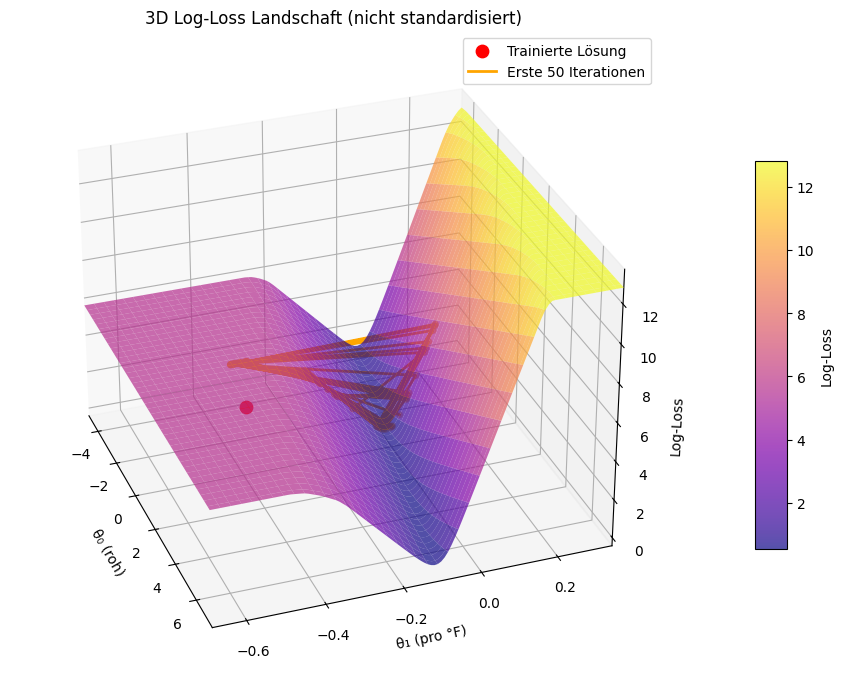

In [25]:
#Die Ergebnisse der Losses mit ganz vielen Theta0-Theta1-Kombis ergibt die Landschaft
#Die Trajektorie ergibt sich aus dem Gradientenabstiegsverfahren
# 3D-Visualisierung der Log-Loss-Landschaft im NICHT standardisierten Parameterraum
# Hier werden die Koeffizienten direkt auf den Rohdaten neu trainiert.
temp_raw = df['temperature'].values
X_raw = np.column_stack([np.ones(len(temp_raw)), temp_raw])

theta_raw, costs_raw, theta_history_raw = train_logreg_simple(X_raw, y, lr=0.01, n_steps=10000)
theta0_raw = theta_raw[0]
theta1_raw = theta_raw[1]

print('Trainierte Koeffizienten (nicht standardisiert):')
print(f'  theta0 (Intercept): {theta0_raw:.6f}')
print(f'  theta1 (Temperatur pro °F): {theta1_raw:.6f}')
print(f'Endkosten (Log-Loss): {costs_raw[-1]:.6f}')

# Visualisierung der ersten 50 Iterationen auf der Rohraum-Landschaft
theta_path_raw = np.array(theta_history_raw[:51]) #Pfad der ersten 50 Iterationen direkt aus dem Rohdaten-Training
path_losses_raw = np.array([compute_cost(X_raw, y, theta_step_raw) for theta_step_raw in theta_path_raw]) #Berechnung der Log-Loss Werte für jeden Punkt auf dem Pfad der ersten 50 Iterationen im Rohraum

# Anzeige an die komplette Iterationsspur anpassen
theta0_raw_min = min(theta_path_raw[:, 0].min(), theta0_raw) 
theta0_raw_max = max(theta_path_raw[:, 0].max(), theta0_raw)
theta1_raw_min = min(theta_path_raw[:, 1].min(), theta1_raw)
theta1_raw_max = max(theta_path_raw[:, 1].max(), theta1_raw)
theta0_margin = max(5.0, 0.4 * (theta0_raw_max - theta0_raw_min))
theta1_margin = max(0.2, 0.4 * (theta1_raw_max - theta1_raw_min))

theta0_raw_range = np.linspace(theta0_raw_min - theta0_margin, theta0_raw_max + theta0_margin, 120)
theta1_raw_range = np.linspace(theta1_raw_min - theta1_margin, theta1_raw_max + theta1_margin, 120)
Theta0_raw, Theta1_raw = np.meshgrid(theta0_raw_range, theta1_raw_range)
Loss_landscape_raw = np.zeros_like(Theta0_raw)

for i in range(Theta0_raw.shape[0]): #Durchlaufen aller Punkte im Gitter des Rohraums
    for j in range(Theta0_raw.shape[1]): 
        theta_temp_raw = np.array([Theta0_raw[i, j], Theta1_raw[i, j]])
        Loss_landscape_raw[i, j] = compute_cost(X_raw, y, theta_temp_raw)

loss_raw = compute_cost(X_raw, y, np.array([theta0_raw, theta1_raw])) #Log-Loss für die im Rohraum trainierte Lösung

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(
    Theta0_raw, Theta1_raw, Loss_landscape_raw,
    cmap='plasma',
    edgecolor='none',
    alpha=0.7
) #Log-Loss Landschaft im Rohraum als Oberfläche
fig.colorbar(surface, shrink=0.6, aspect=12, pad=0.1, label='Log-Loss')

ax.scatter(theta0_raw, theta1_raw, loss_raw, color='red', s=80, label='Trainierte Lösung') #Punkt der trainierten Lösung im Rohraum
ax.plot(theta_path_raw[:, 0], theta_path_raw[:, 1], path_losses_raw, color='orange', linewidth=2, label='Erste 50 Iterationen') #Pfad der ersten 50 Iterationen im Rohraum als Linie
ax.scatter(theta_path_raw[1:, 0], theta_path_raw[1:, 1], path_losses_raw[1:], color='orange', s=18)
ax.set_xlim(theta0_raw_min - theta0_margin, theta0_raw_max + theta0_margin)
ax.set_ylim(theta1_raw_min - theta1_margin, theta1_raw_max + theta1_margin)

ax.set_xlabel('θ₀ (roh)')
ax.set_ylabel('θ₁ (pro °F)')
ax.set_zlabel('Log-Loss')
ax.set_title('3D Log-Loss Landschaft (nicht standardisiert)')
ax.view_init(elev=30, azim=-20)
ax.legend()
plt.tight_layout()
plt.show()